## Tokenization


For transformers, a fundamental step is to convert the input text into a sequence of tokens. Tokenizers are used for this purpose. Different tokenization techniques can be used (e.g., Byte-Pair Encoding).

These tokenizers need to be trained on some corpus (e.g., to figure out what the most common words are). However, the Hugging Face library provides pre-trained tokenizers that can be used out of the box.

Generally, each model has its own tokenizer. For example, the `BertTokenizer` is used for BERT models, and the `GPT2Tokenizer` is used for GPT-2 models.


Since we will be using T5 for this exercise, we should be using the `T5Tokenizer` class. However, HuggingFace provides a common `AutoTokenizer` class that can be used to load the appropriate tokenizer for a given model  (do note, however, that the returned class will be the "correct" one!).

In [ ]:
from transformers import AutoTokenizer

model_name = "google-t5/t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

# TODO: print the type of the tokenizer
print(type(tokenizer))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

<class 'transformers.models.t5.tokenization_t5_fast.T5TokenizerFast'>


### Encoding/Decoding

Tokenization can be carried out by passing a string that we want to tokenize. The tokenizer implements the `__call__` method, so we can call the tokenizer directly, as follows.

Note that the output is a dictionary, which generally has the following keys:

- `input_ids`: The tokenized input text (a list of token IDs by default).
- `attention_mask`: A mask that indicates which elements in the input text are tokens and which are padding tokens. For now, we can ignore this (there is no padding). It will instead become useful when we encode batches of sentences of different lengths at the same time.

In [ ]:
sentence = "hello, this is a sentence!"

# TODO: use the tokenizer to tokenize the sentence and print the result
tokens = tokenizer(sentence)
print(tokens)

{'input_ids': [21820, 6, 48, 19, 3, 9, 7142, 55, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}


We can reverse the encoding operation (i.e., going from token IDs to strings) by using the `decode` method of the tokenizer.

In [ ]:
tokenizer.decode(tokens["input_ids"])

'hello, this is a sentence!</s>'

Note that we have an extra part at the end of the string, which is the special token `</s>`. This token is used to indicate the end of the input text (EOS). This token is automatically added by the tokenizer when encoding the input text.

To learn what the mapping between tokens and token IDs is, we can get the tokenizer's vocabulary (`.get_vocab()`), which provides the mapping between tokens and respective IDs.

For convenience, we build also a reverse vocabulary (i.e., from IDs to tokens).

In [ ]:
import random

vocabulary = tokenizer.get_vocab()


# TODO: print 10 random words from the vocabulary
reverse_vocab = {v: k for k,v in vocabulary.items()}

vocab_keys = list(vocabulary.keys())

random.shuffle(vocab_keys)

{ k: vocabulary[k]  for k in vocab_keys[:10]}


{'▁Offer': 11121,
 '▁Idaho': 19546,
 '▁Movie': 10743,
 '▁fringe': 26533,
 '▁Jerry': 16637,
 '▁nimeni': 14607,
 '▁velvet': 21327,
 'hom': 10207,
 '▁suggest': 3130,
 '▁voyage': 6232}

In [ ]:
print("Total vocabulary size:", len(vocabulary))

Total vocabulary size: 32100


We have a total of 32100. For T5, that's 32000 tokens + 100 special tokens (<extra_id_0>, <extra_id_1>, ..., <extra_id_99>) -- used for the tasks that T5 was trained on.

Let's see what the token id for the special token `</s>` is.

In [ ]:
vocabulary["</s>"]

1

And indeed, note that our `tokens` has a 1 showing up at the end!

In [ ]:
tokens["input_ids"]

[21820, 6, 48, 19, 3, 9, 7142, 55, 1]

We can include special tokens inside of the strings themselves. For instance:

In [ ]:
tokenizer("hello!</s></s>")

{'input_ids': [21820, 55, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1]}

Here, we have 2 `</s>` tokens (the ones we specified), plus an additional one that was added by the tokenizer.

Instead of getting token IDs directly, we may look at the tokens being produced, directly. We use the `tokenize()` method in this case.

In [ ]:
tokenizer.tokenize(sentence)

['▁hello', ',', '▁this', '▁is', '▁', 'a', '▁sentence', '!']

What's up with those `_`? They simply represent words that are starting after spaces. This helps us understand whether a token is being used at the beginning of a sentence, or if it's in the middle of a word.

In [ ]:
print(tokenizer.tokenize("hello    ,world"))
print(tokenizer.tokenize("hello    , world"))

['▁hello', '▁', ',', 'world']
['▁hello', '▁', ',', '▁world']


In the above case, `_hello` is the token for the word "hello" at the beginning of the sentence. However, the word "world" is mapped to two different tokens, depending on whether there is a space before the word or not.

Notice also how multiple spaces are compacted into a single one!

These are all tokenizer-specific details. The tokenizer is responsible for deciding how to tokenize the input text. You may observe different behaviors for different tokenizers.

### Special tokens

Each model typically has its own special tokens. Some are necessary for the training process, while others can be beneficial at inference time.

Special attributes are available in the tokenizer class to access these special tokens. Some examples are:

- `pad_token` is the token used for padding (as discussed later),
- `bos_token` and `eos_token` tokens are used to indicate the beginning and end of the input text, respectively,
- `mask_token` is used for masking tokens during training (e.g., for the masked LM task, with BERT),
- `sep_token` is used to separate sentences in the input text (e.g., next sentence prediction, with BERT),
- `cls_token` is used to indicate the beginning of the input text (e.g., for classification tasks, with BERT),
- `unk_token` is used to indicate unknown tokens (i.e., tokens that are not in the vocabulary).

Of course, not all tokenizers will use all tokens. So those attributes will be set to None, if not used.

For instance, T5 has EOS and PAD tokens, but no BOS token.

In [ ]:
tokenizer.eos_token, tokenizer.pad_token, tokenizer.bos_token

('</s>', '<pad>', None)

The `_id` suffix is used to indicate the corresponding token ID (None if not applicable non è presente per il modello tokenizzato).

In [ ]:
tokenizer.eos_token_id, tokenizer.pad_token_id, tokenizer.bos_token_id

(1, 0, None)

### Batch encoding/decoding

In general (especially at training time) we will want to encode multiple sentences at once (e.g., an entire batch of sentences).

We can pass a list of sentences to be encoded to the tokenizer.

In [ ]:
sentences = [
    "this is the first sentence",
    "instead, this is the second sequence!"
]

#TODO: use the tokenizer to tokenize the sentences and print the result
tokens =tokenizer(sentences)
for tok_sent in tokens['input_ids']:
    print(tok_sent)

[48, 19, 8, 166, 7142, 1]
[1446, 6, 48, 19, 8, 511, 5932, 55, 1]


Of course, sentences of different lengths have a different number of tokens! However, tensors (that will be used by the model) need to have the same number of elements along each dimension.

To do this, we can use padding: all sentences will be padded to the length of the longest sentence in the batch. This is done by adding `pad` tokens (`<pad>`, for T5).

However, since the pad tokens are not part of the input text, we need to let the model know that it should not pay attention to them. That's what the `attention_mask` is for!
(Abbiamo bisogno del padding perche facciamo operizioni tra matrici(prodotti) che non possono essere fatti se le dimensioni sono diverso o comunque non rispettano determinate proporzioni)

In [ ]:
#TODO: use the tokenizer to tokenize the sentences with padding and print the result (use padding=True)
tokens = tokenizer(sentences,padding=True)
for tok_sent, att in zip(tokens['input_ids'],tokens["attention_mask"]):
  print(tok_sent, att)

[48, 19, 8, 166, 7142, 1, 0, 0, 0] [1, 1, 1, 1, 1, 1, 0, 0, 0]
[1446, 6, 48, 19, 8, 511, 5932, 55, 1] [1, 1, 1, 1, 1, 1, 1, 1, 1]


The first sentence is padded to the same length as the second sentence, with 0's (remember, the ID for `<pad>`!).

The attention mask for the first sentence also contains 0's for the padding tokens: the model will ignore them when processing the input text.

Since now all sentences have the same length, we can stack them into a single tensor. Luckily, the tokenizer can already do this for us, we just need to ask.


In [ ]:
#TODO: use the tokenizer to tokenize the sentences with padding as a tensor and print the result (use padding=True and return_tensors="pt")
tokens = tokenizer(sentences, padding=True, return_tensors="pt")

print(tokens["input_ids"])
print(tokens["attention_mask"])

tensor([[  48,   19,    8,  166, 7142,    1,    0,    0,    0],
        [1446,    6,   48,   19,    8,  511, 5932,   55,    1]])
tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1]])


For completeness, we can also decode batches of sentences, with `tokenizer.batch_decode()`.

In [ ]:
tokenizer.batch_decode(tokens["input_ids"])

['this is the first sentence</s><pad><pad><pad>',
 'instead, this is the second sequence!</s>']

## Model analysis

Now we can go ahead and finally load our T5 model. We once again use a pretrained version available on HuggingFace.

In general, we could use the `AutoModel` class for the loading, of the model. However, that version of the model does not include the specific heads for the tasks that T5 was trained on.

The transformers library can make our life easier by defining a family of `AutoModel...` classes.

For instance, the following are some commonly adopted classes:
- `AutoModel`: the base class for all models,
- `AutoModelForSequenceClassification`: a model for sequence classification tasks. It consists of a base model plus a classification head (linear layer + softmax). Note that, generally, the classification head is initialized randomly, and it needs to be trained on the specific task (but the library will let you know with a warning),
- `AutoModelForCaualLM`: a model for causal language modeling tasks (e.g., GPT-2), where we generate the output tokens one by one,
- `AutoModelForMaskedLM`: a model for masked language modeling tasks (e.g., BERT), where we predict the masked tokens in the input text,
- `AutoModelForTokenClassification`: a model for token classification tasks (e.g., NER), where we classify each token in the input text.
- `AutoModelForSeq2SeqLM`: a model for sequence-to-sequence tasks (e.g., T5), where we generate the output tokens one by one in an autoregressive manner, conditioned on the input sequence.

In our specific case, we will use the `AutoModelForSeq2SeqLM` class to be able to generate new tokens.

Analizziamole punto per punto:

Perché non possiamo usare la classe AutoModel per T5? La classe AutoModel in Hugging Face è una classe base generica. Carica l'architettura fondamentale di un modello (come l'encoder e il decoder di T5), ma non include gli "heads" (testine) specifici che sono stati aggiunti e addestrati per particolari task.

T5, ad esempio, è stato addestrato per svolgere una varietà di compiti (traduzione, riassunto, risposta a domande) formulandoli come un task sequence-to-sequence. La capacità di T5 di generare testo come output (che è fondamentale per la traduzione o il riassunto) dipende da una specifica "language modeling head" (testina di modellazione del linguaggio) sul decoder.

Se usassi solo AutoModel, caricheresti solo l'encoder e il decoder di base, ma ti mancherebbe questa testina essenziale per generare sequenze di testo come output. Le classi più specifiche come AutoModelForSeq2SeqLM caricano il modello base insieme alle testine appropriate per il task indicato nel nome della classe.

Poiché vogliamo usare T5 per generare testo (come nella traduzione), abbiamo bisogno della versione del modello che include la testina di modellazione del linguaggio sul decoder, ed è per questo che si usa AutoModelForSeq2SeqLM.

Dove viene usato Hugging Face? Hugging Face è una piattaforma e una libreria Python (transformers) che rende molto più semplice lavorare con modelli di linguaggio di grandi dimensioni (come T5, BERT, GPT-2, ecc.) e altri modelli basati su transformer.

La libreria transformers: Questa libreria fornisce le classi (come AutoTokenizer, AutoModel, AutoModelForSeq2SeqLM) e le funzionalità per caricare modelli e tokenizer pre-addestrati, tokenizzare il testo, eseguire l'inferenza (cioè usare il modello per fare previsioni o generare testo) e addestrare o fine-tuneare i modelli.
Hugging Face Hub (il sito web/piattaforma): Questo è un repository online dove migliaia di modelli, dataset e demo pre-addestrati sono ospitati e resi disponibili pubblicamente (o privatamente). Quando chiami AutoTokenizer.from_pretrained("google-t5/t5-base") o AutoModelForSeq2SeqLM.from_pretrained("google-t5/t5-base"), la libreria transformers scarica automaticamente i pesi e la configurazione del modello "t5-base" (pubblicato da Google) da questo Hub di Hugging Face.
Quindi, Hugging Face viene usato qui sia come la libreria software che stai utilizzando nel codice, sia come la piattaforma da cui stai scaricando il modello pre-addestrato.

Cosa si intende per "Seq2Seq model"? "Seq2Seq" sta per "Sequence-to-Sequence" (Sequenza a Sequenza). È un'architettura di modello neurale progettata per trasformare una sequenza di input in una sequenza di output.

I modelli Seq2Seq sono tipicamente composti da due parti principali:

Un Encoder: Elabora la sequenza di input completa e la comprime in una rappresentazione di "contesto" o "stato latente".
Un Decoder: Prende questa rappresentazione di contesto dall'encoder e genera la sequenza di output un elemento (token) alla volta, basandosi sul contesto e sugli elementi che ha già generato.
T5 è un esempio di modello Seq2Seq. Prende una sequenza di testo in input (ad esempio, la frase in inglese da tradurre) e genera una sequenza di testo in output (la frase tradotta in tedesco). Questa architettura è ideale per task come la traduzione automatica, il riassunto di testo, la risposta a domande (generativa), dove sia l'input che l'output sono sequenze di lunghezza variabile.

In [ ]:
from transformers import AutoModelForSeq2SeqLM
#remember model_name = "google-t5/t5-base"

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# TODO: print the type of the model
print(type(model))


<class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>


To better understand the model, we can take a look at the model's configuration. The configuration contains all the hyperparameters of the model. The configuration is available as a dictionary, and we can access the values by using the attribute notation.

You can find the model's configuration object in the `config` attribute of the model. Or, if you only need the configuration, you can directly load it using the `AutoConfig` class.

```python
from transformers import AutoConfig

config = AutoConfig.from_pretrained(model_name)
```

In [ ]:
model.config

T5Config {
  "architectures": [
    "T5ForConditionalGeneration"
  ],
  "classifier_dropout": 0.0,
  "d_ff": 3072,
  "d_kv": 64,
  "d_model": 768,
  "decoder_start_token_id": 0,
  "dense_act_fn": "relu",
  "dropout_rate": 0.1,
  "dtype": "float32",
  "eos_token_id": 1,
  "feed_forward_proj": "relu",
  "initializer_factor": 1.0,
  "is_encoder_decoder": true,
  "is_gated_act": false,
  "layer_norm_epsilon": 1e-06,
  "model_type": "t5",
  "n_positions": 512,
  "num_decoder_layers": 12,
  "num_heads": 12,
  "num_layers": 12,
  "output_past": true,
  "pad_token_id": 0,
  "relative_attention_max_distance": 128,
  "relative_attention_num_buckets": 32,
  "task_specific_params": {
    "summarization": {
      "early_stopping": true,
      "length_penalty": 2.0,
      "max_length": 200,
      "min_length": 30,
      "no_repeat_ngram_size": 3,
      "num_beams": 4,
      "prefix": "summarize: "
    },
    "translation_en_to_de": {
      "early_stopping": true,
      "max_length": 300,
      "num_

Lots of information going on here. We can just take a few key aspects:

- `d_kv` = 64. This is the dimension of keys $d_k$ (so also queries) and values $d_v$ in the attention mechanism. It is common, to keep things simple, to use the same number of dimensions for keys, queries, and values (even though this is not strictly necessary).
- `d_model` = 768. This is the dimension of the output of each transformer block.
- `d_ff` = 3072. This is the dimension of the feedforward network in each transformer block. We will see that the feedforward network is composed of two linear layers with a ReLU activation in between (`d_model -> d_ff -> d_model`).
- `num_layers` = 12. This is the number of transformer blocks in the model (both encoder and decoder).
- `num_heads` = 12. This is the number of attention heads in the multi-head attention mechanism. Each head will produce a different representation of the input text, and the results will be concatenated together. Remember that the output of each attention head is concatenated. We have 12 heads, each producing a 64-dimensional output, so the final output will be 12 * 64 = 768-dimensional.

We can now inspect the model to better understand its architecture.

In [ ]:
model

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=768, out_features=3072, bias=False)
              (wo): Linear(in_features=3072, out_features=768, bias=False)
              (dropout): Dro

We see that the model has a `shared` Embedding layer, an `encoder` and a `decoder`, and a final `lm_head`.

We can look into the token embedding first.


### Tokens embedding


In [ ]:
model.shared

Embedding(32128, 768)

First, we can verify that this `shared` embedding layer, as the name suggests, is shared between the encoder and the decoder.

We do so by checking the id of the embedding layer with the embedding layers found in the encoder and decoder (`model.encoder.embed_tokens` and `model.decoder.embed_tokens`).

Nei modelli come T5, che hanno sia un encoder che un decoder, sia l'encoder che il decoder hanno bisogno di convertire i token (rappresentati dai loro ID numerici) in vettori numerici (embedding). Questo processo è chiamato "embedding dei token".

Uno strato di embedding è sostanzialmente una tabella o una matrice dove ogni riga corrisponde a un token nel vocabolario e la riga stessa è il vettore di embedding per quel token. Quando il modello ha bisogno dell'embedding di un token, cerca semplicemente la riga corrispondente all'ID del token in questa tabella.

Quando diciamo che lo strato di embedding è "shared" tra encoder e decoder, significa che entrambi usano la stessa esatta tabella (matrice) di embedding. In altre parole, non ci sono due copie separate della tabella di embedding (una per l'encoder e una per il decoder), ma una sola tabella centralizzata che viene utilizzata da entrambi.

Perché si fa così?

Efficienza della memoria: Avere una sola tabella di embedding invece di due riduce notevolmente la quantità di memoria necessaria per il modello, specialmente con vocabolari molto grandi.
Sinergia nell'apprendimento: Usando lo stesso strato di embedding, sia l'encoder che il decoder contribuiscono all'apprendimento di rappresentazioni vettoriali migliori per i token durante l'addestramento. Questo può portare a embedding più robusti e a prestazioni migliori.
Come si verifica che è "shared" controllando l'ID?

In Python, la funzione id() restituisce un numero intero che è l'identità di un oggetto. Questa identità è unica e costante per quell'oggetto durante la sua vita. Due variabili che puntano allo stesso oggetto in memoria avranno lo stesso ID. Due variabili che puntano a oggetti diversi, anche se hanno lo stesso contenuto, avranno ID diversi.

Nel codice che hai visto (id(model.shared) == id(model.encoder.embed_tokens) and id(model.shared) == id(model.decoder.embed_tokens)):

model.shared: Questo si riferisce allo strato di embedding principale che è stato definito per essere condiviso.
model.encoder.embed_tokens: Questo si riferisce allo strato di embedding utilizzato specificamente dall'encoder del modello.
model.decoder.embed_tokens: Questo si riferisce allo strato di embedding utilizzato specificamente dal decoder del modello.
Controllare id(model.shared) == id(model.encoder.embed_tokens) verifica se lo strato di embedding "shared" è lo stesso oggetto in memoria dello strato di embedding dell'encoder. Controllare id(model.shared) == id(model.decoder.embed_tokens) verifica se lo strato di embedding "shared" è lo stesso oggetto in memoria dello strato di embedding del decoder.

Se entrambe queste condizioni sono True, significa che model.shared, model.encoder.embed_tokens, e model.decoder.embed_tokens puntano tutti allo stesso identico oggetto strato di embedding in memoria. Questo conferma che lo strato di embedding è effettivamente condiviso tra l'encoder e il decoder. Se fossero oggetti diversi, anche se con gli stessi pesi iniziali, i loro ID sarebbero diversi.

In [ ]:
id(model.shared) == id(model.encoder.embed_tokens) and id(model.shared) == id(model.decoder.embed_tokens)

True

Next, we note that the embedding layer has 32128 tokens.

This is not exactly the number of tokens we saw before (32100). The extra 28 tokens are "leftovers". 32128 = 251 * 128 is a more "GPU friendly" number, and it's used to speed up the computation (same reason why we often see batch sizes that are powers of 2).

In [ ]:
words = [
    "chair",
    "table",
    "plate",
    "knife",
    "spoon",
    "horse",
    "goat",
    "sheep",
    "cat",
    "dog",
]

In [ ]:
word_tokens = tokenizer(words, return_tensors="pt", padding=True)["input_ids"][:, 0]
print(word_tokens)
token_embeddings = model.shared(word_tokens).cpu().detach().numpy()
print(token_embeddings.shape)

tensor([ 3533,   953,  3829, 10821, 14987,  4952, 18174, 15184,  1712,  1782])
(10, 768)


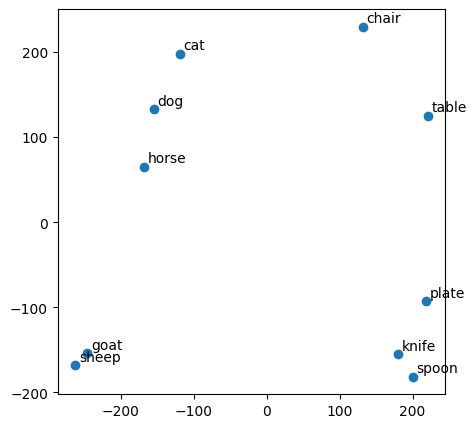

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(token_embeddings)

fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(X_pca[:, 0], X_pca[:, 1])
for i, word in enumerate(words):
    ax.text(X_pca[i, 0]+5, X_pca[i, 1]+5, word)

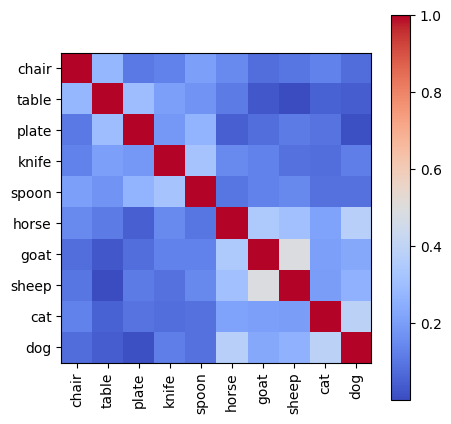

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_similarity(token_embeddings)
fig, ax = plt.subplots(figsize=(5,5))
cax = ax.imshow(cosine_similarity(token_embeddings), cmap="coolwarm")
fig.colorbar(cax)
plt.xticks(range(len(words)), words, rotation=90)
plt.yticks(range(len(words)), words);

### Encoder


The model's encoder contains various transformer layers (each one attention, feed-forward, and normalization layers).

In [ ]:
model.encoder

T5Stack(
  (embed_tokens): Embedding(32128, 768)
  (block): ModuleList(
    (0): T5Block(
      (layer): ModuleList(
        (0): T5LayerSelfAttention(
          (SelfAttention): T5Attention(
            (q): Linear(in_features=768, out_features=768, bias=False)
            (k): Linear(in_features=768, out_features=768, bias=False)
            (v): Linear(in_features=768, out_features=768, bias=False)
            (o): Linear(in_features=768, out_features=768, bias=False)
            (relative_attention_bias): Embedding(32, 12)
          )
          (layer_norm): T5LayerNorm()
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (1): T5LayerFF(
          (DenseReluDense): T5DenseActDense(
            (wi): Linear(in_features=768, out_features=3072, bias=False)
            (wo): Linear(in_features=3072, out_features=768, bias=False)
            (dropout): Dropout(p=0.1, inplace=False)
            (act): ReLU()
          )
          (layer_norm): T5LayerNorm()
          (d

The `block` attribute is a list of `T5Block` modules, and contains the actual transformer layers. Indeed, we can check (as previously stated) that we have 12 encoder layers in the encoder.

In [ ]:
len(model.encoder.block)

12

Each of the modules inside of the `block` is composed of a `T5LayerSelfAttention` module (attention layer), followed by a `T5LayerFF` module (feed-forward layer).

Remember that there are some other details (e.g., normalization layers, or dropouts) that are shown below, but we will not discuss them in detail here.

As a reminder, this is the architecture of a single encoder block.

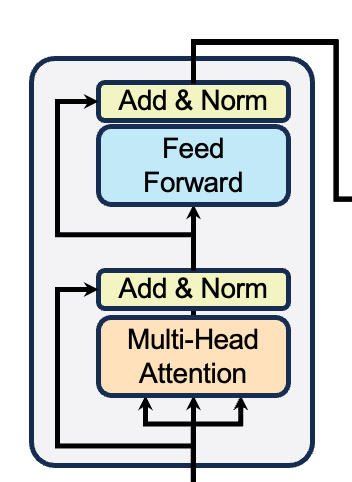![encoder.png](images/encoder.png)

In [ ]:
model.encoder.block[0]

Notice that the $W_q$, $W_k$, and $W_v$ matrices are 768x768. But, we stated that each attention is 64-dimensional, so they should be 768x64!

However, remember that we have 12 heads: instead of producing 12 different heads, we instead efficiently represent all matrices inside of a single matrix. In addition, there is no need for concatenating the results: the output will already be the concatenation of all heads.

The $W_o$ matrix is 768x768, i.e. `d_kv`*`num_heads` x `d_model`, as expected.

### Decoder

We can inspect the decoder in the same way. Remember the decoder's architecture!

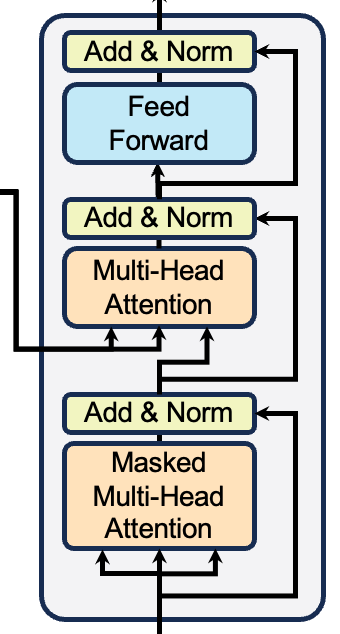

In [ ]:
model.decoder.block[0]

T5Block(
  (layer): ModuleList(
    (0): T5LayerSelfAttention(
      (SelfAttention): T5Attention(
        (q): Linear(in_features=768, out_features=768, bias=False)
        (k): Linear(in_features=768, out_features=768, bias=False)
        (v): Linear(in_features=768, out_features=768, bias=False)
        (o): Linear(in_features=768, out_features=768, bias=False)
        (relative_attention_bias): Embedding(32, 12)
      )
      (layer_norm): T5LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): T5LayerCrossAttention(
      (EncDecAttention): T5Attention(
        (q): Linear(in_features=768, out_features=768, bias=False)
        (k): Linear(in_features=768, out_features=768, bias=False)
        (v): Linear(in_features=768, out_features=768, bias=False)
        (o): Linear(in_features=768, out_features=768, bias=False)
      )
      (layer_norm): T5LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (2): T5LayerFF(
      (DenseReluDense): T5DenseA

Indeed, we find the expected architecture.

An initial self-attention module, followed by a multi-head attention one (`T5LayerCrossAttention`), and finally a feed-forward module.

Note that, although there is a dedicated class for cross-attention, the module still makes use of the same `T5Attention` class we also used for self-attention. This is because nothing changes in the attention mechanism itself: only the inputs are different. (K and V)

Finally, note that the model's `lm_head` is a linear layer that takes the output of the decoder (768-dimensional) and maps it to the vocabulary size (32128).

In [ ]:
model.lm_head

Linear(in_features=768, out_features=32128, bias=False)

## Token generation

Let's now focus on the token generation process.

Remember, we are working with an encoder-decoder architecture. The encoder processes the input text, and the decoder generates the output text.

The input for the encoder is the tokenized input text. We also need to specify an input for the decoder. The decoder's input will be the currently generated sequence thus far. For the first iteration, there is nothing already generated, so we need to specify a special token to indicate the beginning of the sequence (BOS). For T5, the token will be `<pad_token>`.

In [ ]:
import torch

input_sentence = "translate english to german: hello, how are you?"

#TODO: use the tokenizer to tokenize the input sentence as a tensor
tokens = tokenizer(input_sentence,return_tensors="pt")

decoder_input_ids = torch.tensor([[ tokenizer.pad_token_id ]])


T5, invece, utilizza il pad token (<pad>) come token iniziale per il decoder. Questo token segnala al decoder che deve iniziare a generare la sequenza di output. È un po' come dare il "via" al processo di generazione.

In [ ]:
print("Encoder's input")
print(tokens["input_ids"])

print()
print("Decoder's input")
print(decoder_input_ids)

Encoder's input
tensor([[13959, 22269,    12, 13692,    10, 21820,     6,   149,    33,    25,
            58,     1]])

Decoder's input
tensor([[0]])


To generate the first output token (after `<pad_token>`), we call the model's __call__ method (or `forward` method) with the input text and the decoder's input.

**tokens: Questa è una sintassi speciale di Python chiamata "unpacking di dizionario". Il dizionario tokens che hai creato con il tokenizer contiene le chiavi e i valori necessari come input per il modello (tipicamente input_ids e attention_mask). Quando usi **tokens, stai dicendo a Python di prendere tutte le coppie chiave-valore dal dizionario tokens e di passarle alla funzione model come argomenti keyword separati. Quindi, **tokens è equivalente a scrivere input_ids=tokens['input_ids'], attention_mask=tokens['attention_mask'].

In [ ]:
# **tokens passes the dictionary as keyword arguments (input_ids=..., attention_mask=...)
output = model(**tokens, decoder_input_ids=decoder_input_ids)
print(output.keys())

odict_keys(['logits', 'past_key_values', 'encoder_last_hidden_state'])


Certo, approfondiamo il significato di past_key_values e encoder_last_hidden_state negli output del modello.

past_key_values

Questo output è fondamentale per rendere efficiente il processo di generazione di testo, che nei modelli autoregressivi come il decoder di T5 avviene token per token.

Immagina di generare una frase, parola dopo parola. Quando generi la seconda parola, il modello deve considerare la prima parola che ha appena generato. Quando generi la terza parola, deve considerare la prima e la seconda, e così via. Ogni nuovo token generato dipende da tutti i token generati in precedenza.

La parte di "auto-attenzione" del decoder calcola come ogni token attuale si relaziona con i token precedenti nella sequenza generata. Questa computazione coinvolge le matrici Key (K) e Value (V) dei token precedenti.

Ora, pensa a cosa succede nella seconda iterazione di generazione:

L'input per il decoder è il token iniziale (<pad>) più il primo token generato.
Per generare il secondo token, il modello deve calcolare l'attenzione tra il nuovo token e i token precedenti.
Le matrici K e V per il token iniziale <pad> sono già state calcolate nella prima iterazione.
Senza past_key_values, il modello dovrebbe ricalcolare le matrici K e V per tutti i token precedenti ad ogni passo di generazione. Questo sarebbe molto inefficiente, specialmente per sequenze lunghe.

Il valore past_key_values è semplicemente un cache di queste matrici K e V calcolate per i token generati nelle iterazioni precedenti.

Quindi, quando passi past_key_values al modello nella chiamata successiva:

Il modello usa le K e V cached per i token precedenti invece di ricalcolarle.
Calcola le K e V solo per il nuovo token appena aggiunto.
Aggiorna il cache past_key_values con le nuove K e V.
Questo riduce drasticamente la quantità di calcoli necessari ad ogni passo, velocizzando notevolmente il processo di generazione di sequenze.

encoder_last_hidden_state

Questo output rappresenta l'elaborazione finale dell'input originale da parte dell'encoder. L'encoder processa l'intera sequenza di input e la trasforma in una rappresentazione vettoriale (gli hidden states). encoder_last_hidden_state sono gli hidden states prodotti dall'ultimo strato dell'encoder.

Nel processo di generazione standard (come la traduzione o il riassunto), il decoder utilizza questo encoder_last_hidden_state attraverso il suo strato di "cross-attenzione". La cross-attenzione permette al decoder di "guardare" (attendere) l'input originale (rappresentato dagli hidden states dell'encoder) mentre genera la sequenza di output.

Tuttavia, l'output encoder_last_hidden_state in sé non viene utilizzato direttamente per generare il prossimo token nel senso di essere l'input diretto per la predizione finale del token. Viene invece usato all'interno del decoder dallo strato di cross-attenzione per fornire contesto dall'input originale.

Il testo menziona che "we may find it useful for other tasks (e.g., summarization)". Questo è vero in un contesto più ampio. Ad esempio, se stessi addestrando un modello T5 per un nuovo compito che richiede l'accesso alla rappresentazione codificata dell'input (magari per un compito di classificazione basato sull'input intero), potresti voler estrarre e utilizzare questo encoder_last_hidden_state. Ma per la semplice generazione di testo una volta che il modello è addestrato, il suo uso principale è come input per la cross-attenzione del decoder.

In sintesi:

past_key_values serve a velocizzare la generazione token-by-token nel decoder, memorizzando i calcoli precedenti.
encoder_last_hidden_state è la rappresentazione elaborata dell'input originale da parte dell'encoder, utilizzata dal decoder tramite la cross-attenzione per avere contesto sull'input mentre genera l'output.

We get three outputs:

- `logits`: The logits for each token in the vocabulary. The logits are the output of the linear layer (the `lm_head`) that maps the decoder's output to the vocabulary size. The logits are used to compute the probabilities of each token.

- `past_key_values`: The past key-values of the decoder. This is used to speed up the generation process for future tokens. Remember: the decoder is autoregressive, so we generate one token at a time. Since each token can only pay attention to past tokens, it means that the predictions made for earlier tokens will not change. Thus, we can cache them and not re-compute them. So, if we pas `past_key_values` to the model the next time we call it, it will be faster.

- `encoder_last_hidden_state`: The hidden states of the last layer of the encoder. This is not used for generating the next token, but we may find it useful for other tasks (e.g., summarization).

In [ ]:
print(output.logits.shape)

torch.Size([1, 1, 32128])


The shape of the logits is 1x1x32128. The first dimension is the batch size, the second dimension is the number of tokens in the output sequence (we are still at a single generated token), and the third dimension is the number of tokens in the vocabulary.

So what's the next word going to be? We can use greedy decoding to take the token with the highest probability.

In [ ]:
max_proba_token = output.logits[0,0].argmax()
print("Max probability token:", max_proba_token.item())
print("Corresponding token:", tokenizer.decode(max_proba_token))

Max probability token: 2501
Corresponding token: Hall


Looks like we're on the right track. We have a new token, which we can add to our `decoder_input_ids` tensor and continue with the next iteration.


In [ ]:
# .view() acts like .reshape(), but assumes that the tensor is contiguous in memory (& is faster)
decoder_input_ids = torch.hstack([decoder_input_ids, max_proba_token.view(1, 1)])
print(decoder_input_ids)

tensor([[   0, 2501]])


In [ ]:
#TODO: use the model to generate the next token
output = model(**tokens,decoder_input_ids=decoder_input_ids)
output.logits.shape

torch.Size([1, 2, 32128])

Now the output has shape 1x2x32128. We have generated two tokens!

The first one, remember, will necessarily be the same as the one we produced before, since the masking mechanism prevents the model from seeing any following token.

But just to be sure, let's decode both tokens.

In [ ]:
# 0 -> first (and only) batch
max_proba_tokens = output.logits[0].argmax(axis=1) # output.logits[0]: Questa parte seleziona il primo elemento lungo la dimensione del batch. Poiché stai elaborando una singola frase alla volta (batch size = 1), output.logits[0] seleziona l'unico elemento nel batch. Il tensore risultante avrà forma [sequence_length, vocab_size].
print("Token ids", max_proba_tokens)
print("Mapped tokens", list(map(reverse_vocab.get, max_proba_tokens.tolist())))
print("Decoded string", tokenizer.decode(max_proba_tokens))

Token ids tensor([2501,   32])
Mapped tokens ['▁Hall', 'o']
Decoded string Hallo


We are onto something. We could go ahead and generate more tokens manually.

However, we can implement our own generation loop.

In [ ]:
# greedy deoding
tokenizer.batch_decode(model.generate(**tokens, do_sample=True))

['<pad> Hallo, wie sind Sie jetzt?</s>']

In [ ]:
output.logits[0].argmax(axis=1)

tensor([2501,   32])

In [ ]:

decoder_input_ids = torch.tensor([[ tokenizer.pad_token_id ]])

max_length = 50
i = 0

while i < max_length and decoder_input_ids[0,-1] != tokenizer.eos_token_id:
    output = model(**tokens, decoder_input_ids=decoder_input_ids)
    max_proba_tokens = output.logits[0].argmax(axis=1)
    print(f"Step {i+1}: {tokenizer.decode(max_proba_tokens)}")
    decoder_input_ids = torch.hstack([decoder_input_ids, max_proba_tokens[-1].view(1, 1)])
    i += 1

Step 1: Hall
Step 2: Hallo
Step 3: Hallo,
Step 4: Hallo, wie
Step 5: Hallo, wie sind
Step 6: Hallo, wie sind Sie
Step 7: Hallo, wie sind Sie?
Step 8: Hallo, wie sind Sie?</s>


Note that we are introducing a `max_length` parameter. This is just in case, to prevent the model from generating an infinite sequence.

Now, turns out that the model has a `generate()` method that does exactly what we just did.

Senza do_sample=True (o con do_sample=False, che è il default per molti modelli), la generazione avviene tramite decoding greedy (decodifica avida). Come abbiamo visto prima, questo significa che ad ogni passo il modello sceglie semplicemente il token con la probabilità più alta (quello con il logit maggiore) tra tutti i possibili token nel vocabolario. Questo approccio è deterministico: data la stessa input, otterrai sempre lo stesso output. Tuttavia, può portare a testo ripetitivo o generico.

Quando imposti do_sample=True, abiliti la generazione basata sul campionamento. Invece di scegliere sempre il token più probabile, il modello considera le probabilità di tutti i token nel vocabolario per il passo corrente e campiona (sceglie casualmente, ma con probabilità) un token in base alla loro distribuzione di probabilità.

Immagina di avere le probabilità per i prossimi token: "cane" (80%), "gatto" (10%), "topo" (5%), "uccello" (5%).

Con decoding greedy (do_sample=False), sceglieresti sempre "cane".
Con campionamento (do_sample=True), potresti scegliere "cane" l'80% delle volte, "gatto" il 10%, ecc., in modo casuale.
Vantaggi di do_sample=True:

Varietà: La generazione basata sul campionamento introduce una maggiore casualità e varietà nell'output. Ogni volta che esegui la generazione con lo stesso input, potresti ottenere un output leggermente diverso.
Creatività/Fluidità: Spesso produce testo che suona più naturale, meno ripetitivo e potenzialmente più creativo, poiché non è sempre "bloccato" sulla scelta più ovvia.

In [ ]:
#TODO: use the model to generate a translation of the input sentence
out_tokens = model.generate(**tokens,do_sample=True)
tokenizer.batch_decode(out_tokens)

['<pad> Hallo, wie sind Sie?</s>']

In [ ]:
out_tokens = model.generate(**tokens,do_sample=True)
tokenizer.batch_decode(out_tokens)

['<pad> Hallo, wie bist Du?</s>']

You may also empirically verify that `model.generate()` is faster than the manual loop. This is because there are some optimizations in the `generate()` method that make the generation process faster (e.g., caching the encoder's outputs, or the previous decoder's hidden states).

## Cross-attention

We can now run the previous code, but now let's compute the cross-attention weights. This will help us understand what the model is paying attention to in the input sequence, when generating the next token.

To compute the attention weights, we need to reload the model, passing the `output_attentions=True` parameter. This will make the model return the attention weights for each layer.

In [ ]:
#TODO: load the model that returns also the output of the attentions (output_attentions=True)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name, output_attentions=True)

In [ ]:
# re-prepare encoder tokens and decoder tokens
# input_sentence = "translate from english to german: hello how are you?"
input_sentence = "translate english to german: hello how are you?"

#TODO: use the tokenizer to tokenize the input sentence as a tensor
tokens = tokenizer(input_sentence, return_tensors="pt")

#TODO: create the token for the decoder input (start with the <pad> token -> tokenizer.pad_token_id)
decoder_input_ids = torch.tensor([[tokenizer.pad_token_id]])
print(decoder_input_ids.shape)
#TODO: use the model to generate the output putting the decoder_input_ids as the first token (decoder_input_ids=decoder_input_ids)
output = model(**tokens, decoder_input_ids=decoder_input_ids)
print(output.keys())

torch.Size([1, 1])
odict_keys(['logits', 'past_key_values', 'decoder_attentions', 'cross_attentions', 'encoder_last_hidden_state', 'encoder_attentions'])


In [ ]:
#TODO: pass in the tokenizer.batch_decode the output of the model to get the translation of the input sentence
# `tokenizer.batch_decode() is the funnction that decodes the tokenized output of the model into a string`
logits=output['logits']
tokenizer.batch_decode(logits[0].argmax(axis=1))

['Hall']

In addition to the previous values, we now have `decoder_attentions`, `cross_attentions`, and `encoder_attentions`.

The names are self-explanatory. We will focus on the cross-attention to understand encoder-decoder interactions.

Each of the decoder's layers has a corresponding cross-attention layer. So we expect to have 12 cross-attention layers. Indeed, the `cross_attention` is a tuple, with 12 elements.

In [ ]:
type(output.cross_attentions), len(output.cross_attentions)

(tuple, 12)

The shape of any one of these attentions is the following: 1x12x1x11. Remember:

- the first 1 is the batch size (a single sentence),
- 12 are the attention heads, each one producing an attention mask,
- 1 is the number of tokens passed as input to the decoder (just BOS, for now),
- 11 is the number of tokens in the input sequence.

In [ ]:
output.cross_attentions[0].shape

torch.Size([1, 12, 1, 11])

Let's look at the first layer's attentions.

We can see that for early stages the attention is mostly focused on identifying the task ("translate", "english", "german").

Interestingly, "german" gets attention from many of the heads, whereas "translate" and "english" are less attended to. We can expect this to be the case since T5 has been trained on various tasks, one of which was translation from english to other languages.

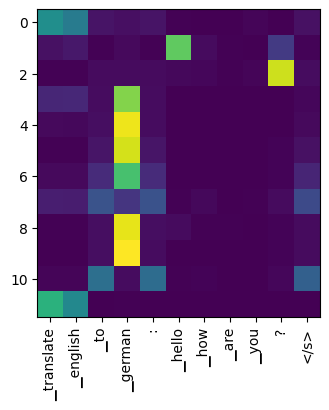

In [ ]:
fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(output.cross_attentions[0][0, :, 0].detach().numpy())
input_tokens = tokenizer.tokenize(input_sentence) + [ "</s>" ]
ax.set_xticks(range(len(input_tokens)), input_tokens, rotation=90);

We can check the rest of the attentions in the other layers as well.

With the exception of the initial layer, the attention on "translate" and "english" is mostly gone. The attention is now focused on "german" and on the first word of the sentence ("hello").


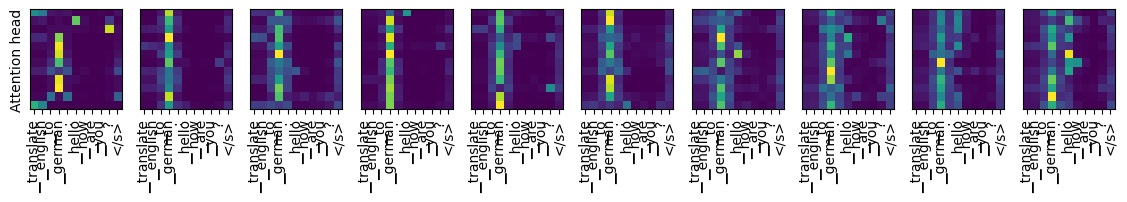

In [ ]:
fig, ax = plt.subplots(1, 10, figsize=(14, 3))

ax[0].set_ylabel("Attention head")

for i in range(10):
    ax[i].imshow(output.cross_attentions[i][0, :, 0].detach().numpy())
    input_tokens = tokenizer.tokenize(input_sentence) + [ "</s>" ]
    ax[i].set_xticks(range(len(input_tokens)), input_tokens, rotation=90);
    ax[i].set_yticks([])

As a final exploration, let's check the average attention across layers and heads, for the last token generated throughout the entire sequence.

In this way, we can observe how the attention shifts as we generate more tokens.

In [ ]:
decoder_input_ids = torch.tensor([[ tokenizer.pad_token_id ]])

attns = []

max_length = 50
i = 0

while i < max_length and decoder_input_ids[0,-1] != tokenizer.eos_token_id:
    output = model(**tokens, decoder_input_ids=decoder_input_ids)
    max_proba_tokens = output.logits[0].argmax(axis=1)
    print(f"Step {i+1}: {tokenizer.decode(max_proba_tokens)}")
    decoder_input_ids = torch.hstack([decoder_input_ids, max_proba_tokens[-1].view(1, 1)])
    attns.append(output.cross_attentions)
    i += 1

Step 1: Hall
Step 2: Hallo
Step 3: Hallo,
Step 4: Hallo, wie
Step 5: Hallo, wie sind
Step 6: Hallo, wie sind Sie
Step 7: Hallo, wie sind Sie?
Step 8: Hallo, wie sind Sie?</s>


Note: taking the average across all heads and all layers may not necessarily be the best approach (for instance, some interesting aspects may be lost in this aggregation). However, it should give us a general idea of what the model is focusing on.

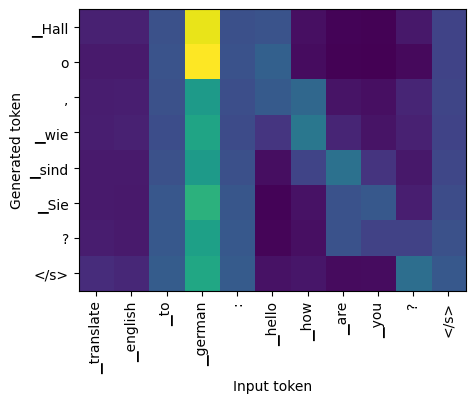

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(torch.stack([ torch.stack(a).mean(axis=(0, 1, 2))[-1] for a in attns ]).detach().numpy())
ax.set_xlabel("Input token")
ax.set_ylabel("Generated token")

input_tokens = tokenizer.tokenize(input_sentence) + [ "</s>" ]
output_tokens = tokenizer.tokenize(tokenizer.decode(output.logits[0].argmax(axis=1)))
ax.set_xticks(range(len(input_tokens)), input_tokens, rotation=90)
ax.set_yticks(range(len(output_tokens)), output_tokens);

Means of attentions for all the 12 layer and the 12 heads in each layer of the last token generated

Indeed, when Hall|o|, is generated, the most attention is paid to the word "hello". Then the attention shifts to the rest of the sentence gradually. This shows how the decoder can focus on different parts of the input sequence as it generates different parts of the output sequence!

Cosa vedi:

Quando genera "_Hall" (inizio di "Hallo"):

Attenzione alta su "hello" (giallo brillante)
Ha capito che deve tradurre questa parola!


Quando genera "o" (completando "Hallo"):

Ancora attenzione su "hello"


Quando genera ",":

Attenzione ancora su "hello" e la virgola dell'input


Quando genera "_wie" (traduzione di "how"):

L'attenzione si sposta gradualmente verso "how"


Quando genera "_sind" e "Sie" (traduzione di "are you"):

L'attenzione si sposta su "are" e "you"



Perché è importante:
Questo dimostra che il decoder guarda dinamicamente diverse parti dell'input mentre genera l'output! Non traduce parola per parola in modo rigido, ma:

Capisce il contesto
Si concentra sulle parti rilevanti dell'input
Sposta l'attenzione progressivamente

È la visualizzazione dell'alignment tra input e output! 🎯
Vedi come l'attention "segue" la traduzione? Prima "hello", poi "how", poi "are you"! Fantastico, no? 😊